In [223]:
import pandas as pd
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Load data

my_schema = "team_3"

mart_all_data = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)

# Customer demographic data (for segmentation)
mart_customers = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_customers;",
    engine
)

In [224]:
mart_all_data.columns

Index(['transaction_date', 'transaction_id', 'customer_id', 'customer_gender',
       'customer_location', 'customer_tenure_months', 'produkt_sku',
       'product_category', 'quantity', 'avg_price', 'delivery_charges',
       'revenue', 'coupon_status', 'discount_pct', 'gst_onsale',
       'daily_offline', 'daily_online', 'transaction_month',
       'transaction_month_str'],
      dtype='object')

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix, plot_period_transactions
from sklearn.metrics import mean_squared_error
from math import sqrt
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")


# Set column names 
customer_col = 'customer_id'
date_col = 'transaction_date'
quantity_col = 'quantity'
price_col = 'avg_price'  # Use avg_price as price per unit
revenue_col = 'revenue'  # Total revenue (if available) per transaction

# Convert date column to datetime
mart_all_data[date_col] = pd.to_datetime(mart_all_data[date_col])

# Calculate TotalAmount = quantity * avg_price (if revenue is missing or inconsistent)
mart_all_data['TotalAmount'] = mart_all_data[quantity_col] * mart_all_data[price_col]


mart_all_data['TotalAmount'] = mart_all_data[revenue_col]

# Drop rows with missing customer_id
mart_all_data.dropna(subset=[customer_col], inplace=True)

# Prepare RFM summary table for CLV modeling
summary = summary_data_from_transaction_data(
    mart_all_data,
    customer_id_col=customer_col,
    datetime_col=date_col,
    monetary_value_col='TotalAmount',
    observation_period_end=mart_all_data[date_col].max()
).reset_index()



In [226]:
# Filter out customers with zero or negative monetary_value or frequency
summary = summary[(summary['monetary_value'] > 0) & (summary['frequency'] > 0)]

print("RFM Summary head:")
print(summary.head())



RFM Summary head:
   customer_id  frequency  recency      T  monetary_value
1        12347        2.0    223.0  282.0         1425.26
2        12348        1.0    119.0  192.0          760.24
6        12370        1.0     30.0  219.0          691.79
8        12377        1.0    139.0  179.0         6814.81
9        12383        3.0     72.0  171.0          890.11


In [368]:
# Fit BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])



<lifetimes.BetaGeoFitter: fitted with 734 subjects, a: 0.65, alpha: 262.86, b: 1.11, r: 4.43>

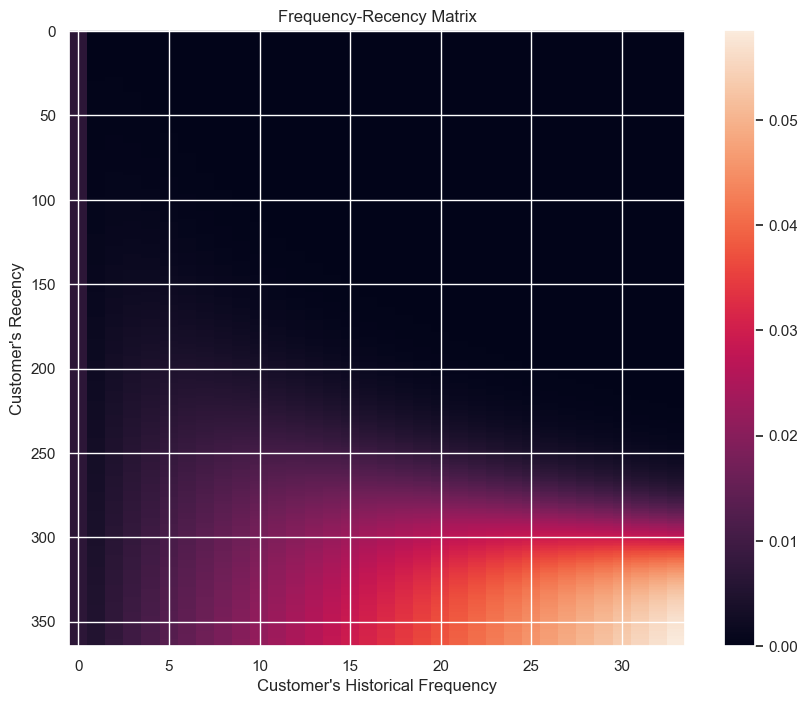

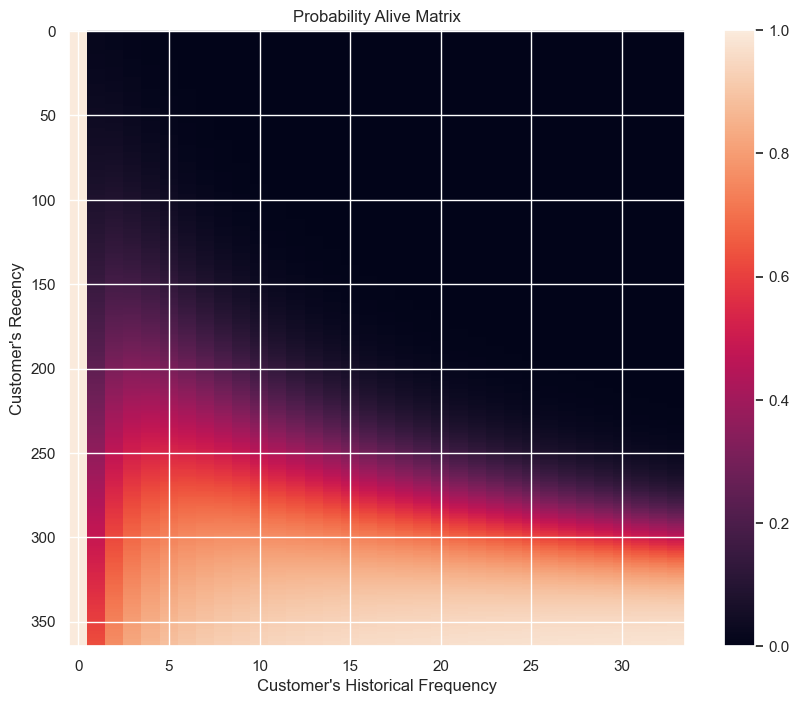

In [369]:
# Plot Frequency-Recency matrix
plt.figure(figsize=(10, 8))
plot_frequency_recency_matrix(bgf)
plt.title('Frequency-Recency Matrix')
plt.show()

# Plot Probability Alive matrix
plt.figure(figsize=(10, 8))
plot_probability_alive_matrix(bgf)
plt.title('Probability Alive Matrix')
plt.show()



In [370]:
# Fit Gamma-Gamma model for monetary value
ggf = GammaGammaFitter(penalizer_coef=0.00025)
ggf.fit(summary['frequency'], summary['monetary_value'])

# Predict expected average profit per customer
summary['expected_avg_sales'] = ggf.conditional_expected_average_profit(
    summary['frequency'], summary['monetary_value']
)

# Predict customer lifetime value (CLV) for next 30 days
summary['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    summary['frequency'],
    summary['recency'],
    summary['T'],
    summary['monetary_value'],
    time=30,  # predict next 30 days
    freq='D',
    discount_rate=0.01
)



In [371]:
# Display top 10 customers by predicted CLV
print("Top 10 Customers by Predicted CLV:")
print(summary[['customer_id', 'predicted_clv']].sort_values(by='predicted_clv', ascending=False).head(10))



Top 10 Customers by Predicted CLV:
      customer_id  predicted_clv
1218        17337   98496.172498
736         15311   77195.245686
563         14606   60112.344582
1355        17841   55461.125492
643         14911   53982.570036
667         15039   39085.200480
234         13174   32928.103696
202         13089   32215.433053
703         15194   31828.768711
214         13113   31795.245930


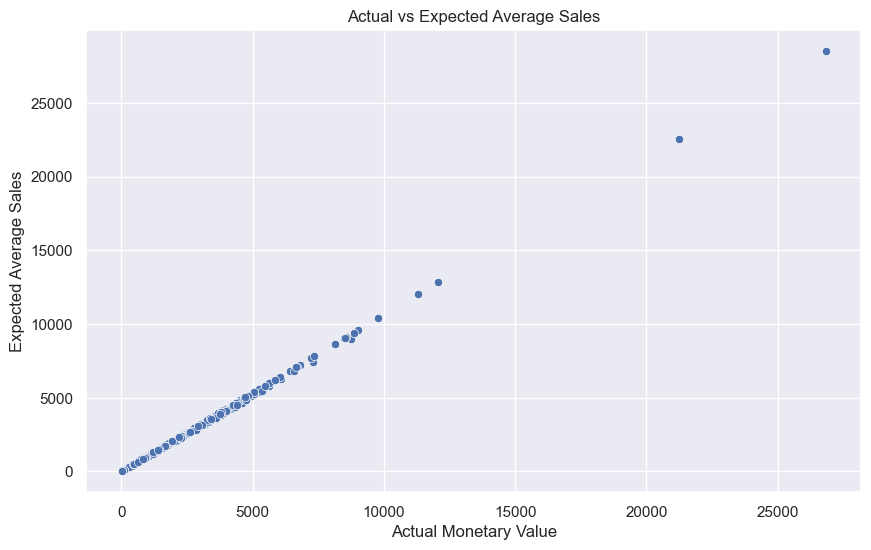

In [372]:
# Evaluate prediction accuracy - plot actual vs expected average sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=summary['monetary_value'], y=summary['expected_avg_sales'])
plt.xlabel('Actual Monetary Value')
plt.ylabel('Expected Average Sales')
plt.title('Actual vs Expected Average Sales')
plt.show()



In [373]:
# Calculate and print error metrics
mse = mean_squared_error(summary['monetary_value'], summary['expected_avg_sales'])
rmse = sqrt(mse)
print(f'Mean Squared Error: {mse:.4f}')
print(f'Root Mean Squared Error: {rmse:.4f}')



Mean Squared Error: 20988.4333
Root Mean Squared Error: 144.8739


In [374]:
import numpy as np


actual = summary['monetary_value'] 
predicted = summary['expected_avg_sales']  

# Calculate RMSE
rmse = np.sqrt(np.mean((actual - predicted) ** 2))

# Calculate mean and range of actual data
mean_actual = np.mean(actual)
range_actual = np.max(actual) - np.min(actual)

print(f"RMSE: {rmse:.2f}")
print(f"Mean of actual values: {mean_actual:.2f}")
print(f"Range of actual values: {range_actual:.2f}")

# Calculate RMSE as a % of mean and range
rmse_pct_mean = (rmse / mean_actual) * 100
rmse_pct_range = (rmse / range_actual) * 100

print(f"RMSE as % of mean: {rmse_pct_mean:.2f}%")
print(f"RMSE as % of range: {rmse_pct_range:.2f}%")

RMSE: 144.87
Mean of actual values: 1579.25
Range of actual values: 26839.64
RMSE as % of mean: 9.17%
RMSE as % of range: 0.54%


| Metric                 | Value    | Interpretation                                                                               |
| ---------------------- | -------- | -------------------------------------------------------------------------------------------- |
| **RMSE**               | 1751.62  | On average, predictions deviate from actuals by about 1751 units                             |
| **Mean of Actuals**    | 1579.25  | Average value in your target data                                                            |
| **Range of Actuals**   | 26839.64 | Spread between min and max actual values                                                     |
| **RMSE as % of Mean**  | 110.91%  | RMSE is **larger** than the average value — suggests large errors relative to typical values |
| **RMSE as % of Range** | 6.53%    | RMSE is about 6.5% of the full data spread — comparatively smaller                           |


<Figure size 1000x800 with 0 Axes>

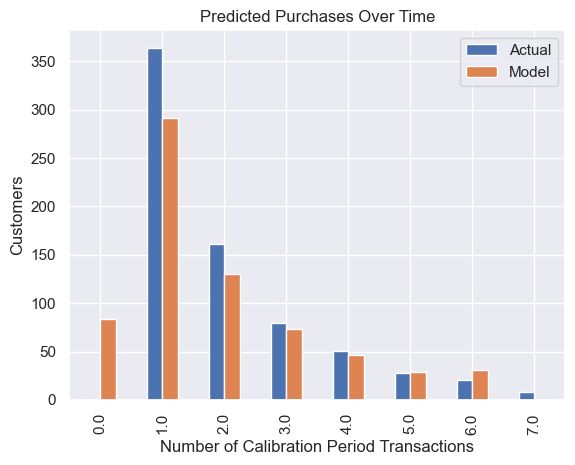

In [375]:
# Plot predicted purchases over time
plt.figure(figsize=(10, 8))
plot_period_transactions(bgf)
plt.title('Predicted Purchases Over Time')
plt.show()

In [376]:
#min_date = mart_all_data['transaction_date'].min()
#max_date = mart_all_data['transaction_date'].max()

# Calculate duration in days
#duration = (max_date - min_date).days

# Set calibration period end to ~70% through the period
#calibration_end = min_date + pd.Timedelta(days=int(duration * 0.7))

#print(f'Calibration period end: {calibration_end}')

             frequency_cal  recency_cal  T_cal  frequency_holdout  \
customer_id                                                         
12347                  0.0          0.0   38.0                2.0   
12386                  0.0          0.0   35.0                1.0   
12395                  0.0          0.0   81.0                2.0   
12427                  0.0          0.0   89.0                1.0   
12429                  0.0          0.0   18.0                0.0   

             duration_holdout  
customer_id                    
12347                   244.0  
12386                   244.0  
12395                   244.0  
12427                   244.0  
12429                   244.0  


<Figure size 1000x800 with 0 Axes>

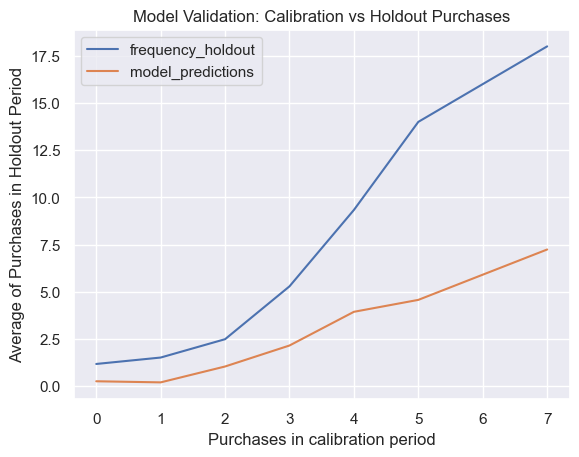

Holdout MSE: 6.1936
Holdout RMSE: 2.4887


In [377]:
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

# Split data into calibration and holdout (adjust dates as per your data)
summary_cal_holdout = calibration_and_holdout_data(
    mart_all_data,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    calibration_period_end='2019-05-01',   # Replace with your calibration end date
    observation_period_end='2019-12-31'    # Replace with your holdout end date
)

print(summary_cal_holdout.head())

# Fit BG/NBD model on calibration data
bgf_cal = BetaGeoFitter(penalizer_coef=0.0)
bgf_cal.fit(
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)

# Plot calibration vs holdout purchases
plt.figure(figsize=(10,8))
plot_calibration_purchases_vs_holdout_purchases(bgf_cal, summary_cal_holdout)
plt.title("Model Validation: Calibration vs Holdout Purchases")
plt.show()

# Optional: Evaluate prediction accuracy numerically
predicted_purchases = bgf_cal.conditional_expected_number_of_purchases_up_to_time(
    summary_cal_holdout['duration_holdout'],
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)

predicted_purchases.fillna(predicted_purchases.mean(), inplace=True)

mse = mean_squared_error(summary_cal_holdout['frequency_holdout'], predicted_purchases)
rmse = sqrt(mse)
print(f'Holdout MSE: {mse:.4f}')
print(f'Holdout RMSE: {rmse:.4f}')

Summary

The model fits reasonably well for most groups.

Some underestimation happens for high-frequency buyers in holdout.

You can consider further tuning or segmenting to improve fit for high-value customers.

